# 🔬 Autoencoder Models on EMNIST
## Image Compression & Reconstruction

| Model | Type | Bottleneck | Key Design |
|-------|------|-----------|------------|
| ANN-1 | Fully Connected | 32 | Shallow: 784 → 256 → 128 → **32** → ... |
| ANN-2 | Fully Connected | 64 | Deep: 784 → 512 → 256 → 128 → **64** → ... + BN + Dropout |
| CNN-1 | Convolutional | 32 | 3× stride-2 Conv + FC(**32**) |
| CNN-2 | Convolutional | 64 | 4× Conv + BN + FC(**64**) |

### Autoencoder Pipeline
```
Input Image (1×28×28)
      │
   [Encoder] — compresses spatial features into a compact code
      │
  Latent z   — bottleneck (32 or 64 floats)
      │
   [Decoder] — reconstructs the image from z
      │
Reconstructed Image (1×28×28)

Loss = MSE(input, reconstruction)  minimised via Adam
```


## 0. Imports & Device Setup

In [1]:
import os, time, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU compatibility check
def get_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    try:
        major, minor = torch.cuda.get_device_capability()
        if major >= 7:
            return torch.device("cuda")
        else:
            print(f"GPU detected ({torch.cuda.get_device_name()}, sm_{major}{minor}) but PyTorch requires sm_70+.")
            return torch.device("cpu")
    except Exception as e:
        print(f"GPU probe failed ({e}). Using CPU.")
        return torch.device("cpu")

DEVICE  = get_device()
OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Device  : {DEVICE}")
print(f"Outputs : {OUT_DIR}")

Device  : cuda
Outputs : /content/outputs


## 1. Dataset — EMNIST Letters

**Source:** `torchvision.datasets.EMNIST` — same data as [Kaggle crawford/emnist](https://www.kaggle.com/datasets/crawford/emnist)  
**Split used:** `letters`  — 26 classes (a–z), handwritten, 28 × 28 greyscale  
**Sizes:** 124,800 train → 90/10 → 112,320 train / 12,480 val | 20,800 test

Labels are **1-based** in EMNIST letters (1 = 'a', 26 = 'z').


In [2]:
IMG_SIZE = 28
BATCH_SIZE = 256
VAL_FRAC = 0.10

transform = transforms.Compose([transforms.ToTensor()])

full_train = datasets.EMNIST(root="/content/data", split="letters", train=True, download=True, transform=transform)
test_set = datasets.EMNIST(root="/content/data", split="letters", train=False, download=True, transform=transform)

n_val = int(len(full_train) * VAL_FRAC)
n_trn = len(full_train) - n_val
train_set, val_set = random_split(full_train, [n_trn, n_val], generator=torch.Generator().manual_seed(SEED))

kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=(DEVICE.type == "cuda"))
train_loader = DataLoader(train_set, shuffle=True, **kw)
val_loader = DataLoader(val_set, shuffle=False, **kw)
test_loader = DataLoader(test_set, shuffle=False, **kw)

print(f"Data ready: {n_trn} training samples, {n_val} validation samples.")

100%|██████████| 562M/562M [00:02<00:00, 234MB/s]


Data ready: 112320 training samples, 12480 validation samples.


### Visualise Sample Images

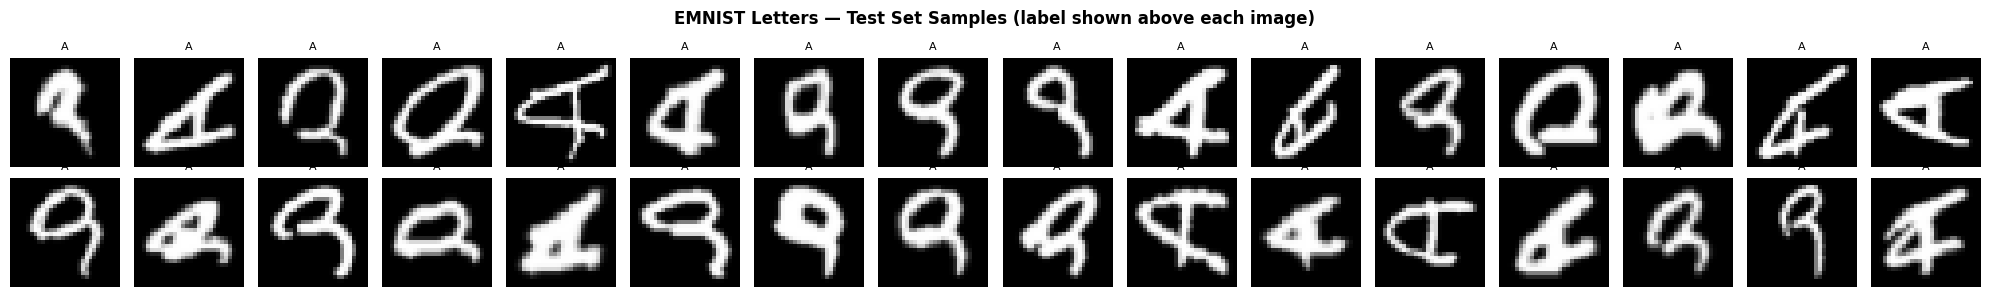

Labels (raw 1-26): [1]
Letters: ['A']


In [3]:
imgs, labels = next(iter(test_loader))

# EMNIST letters: label 1='a'…26='z'; +64 maps to ASCII 'A'…'Z' for display
fig, axes = plt.subplots(2, 16, figsize=(20, 3))
for i in range(32):
    ax = axes[i // 16][i % 16]
    ax.imshow(imgs[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    letter = chr(labels[i].item() + 64)   # 1→'A', 2→'B', …
    ax.set_title(letter, fontsize=8)
    ax.axis('off')

plt.suptitle("EMNIST Letters — Test Set Samples (label shown above each image)",
             fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/0_dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()

unique_labels = sorted(set(labels[:32].tolist()))
print("Labels (raw 1-26):", unique_labels)
print("Letters:", [chr(l + 64) for l in unique_labels])


## 2. Model Architectures

All four models are built **from scratch** using PyTorch — no pretrained weights.

```
INPUT_DIM = 28 × 28 = 784 pixels
```


### [ANN-1]  Shallow FC Autoencoder — Bottleneck 32
```
Encoder:  784 → Linear(256) → ReLU → Linear(128) → ReLU → Linear(32) → ReLU
Decoder:   32 → Linear(128) → ReLU → Linear(256) → ReLU → Linear(784) → Sigmoid
```
Simple baseline — no regularisation, minimal depth.


In [4]:
INPUT_DIM = IMG_SIZE * IMG_SIZE

class ANN_AE_1(nn.Module):
    def __init__(self, bottleneck=32):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder = nn.Sequential(nn.Linear(INPUT_DIM, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, bottleneck), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(bottleneck, 128), nn.ReLU(), nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, INPUT_DIM), nn.Sigmoid())
    def forward(self, x):
        z = self.encoder(x.view(x.size(0), -1))
        out = self.decoder(z).view(x.size(0), 1, IMG_SIZE, IMG_SIZE)
        return out, z

### [ANN-2]  Deep FC Autoencoder — Bottleneck 64
```
Encoder:  784 → [Linear(512)+BN+LReLU+Drop] → [256+BN+LReLU+Drop] → [128+BN+LReLU] → 64
Decoder:   64 → [128+BN+LReLU] → [256+BN+LReLU+Drop] → [512+BN+LReLU+Drop] → 784+Sigmoid
```
Deeper + BatchNorm + Dropout → better generalisation, richer codes.


In [5]:
class ANN_AE_2(nn.Module):
    def __init__(self, bottleneck=64, drop=0.2):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(INPUT_DIM, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.LeakyReLU(0.1),
            nn.Linear(128, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1),
            nn.Linear(128, 256),        nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(256, 512),        nn.BatchNorm1d(512), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(512, INPUT_DIM),  nn.Sigmoid(),
        )

    def forward(self, x):
        z   = self.encoder(x.view(x.size(0), -1))
        out = self.decoder(z).view(x.size(0), 1, IMG_SIZE, IMG_SIZE)
        return out, z

### [CNN-1]  Lightweight Convolutional Autoencoder — Bottleneck 32
```
Encoder: 1×28×28
  Conv(1→8,  k=3,s=2,p=1)+ReLU → 8×14×14
  Conv(8→16, k=3,s=2,p=1)+ReLU → 16×7×7
  Conv(16→32,k=3,s=2,p=1)+ReLU → 32×4×4 → Flatten → Linear(32)

Decoder: 32 → Linear(32×4×4) → Reshape(32,4,4)
  ConvT(32→16,k=3,s=2,p=1,op=0)+ReLU → 16×7×7
  ConvT(16→8, k=3,s=2,p=1,op=1)+ReLU → 8×14×14
  ConvT(8→1,  k=3,s=2,p=1,op=1)+Sigmoid → 1×28×28
```
Spatial inductive bias → fewer parameters than ANN for same quality.


In [6]:
class CNN_AE_1(nn.Module):
    def __init__(self, bottleneck=32):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1,  8,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8,  16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(32 * 4 * 4, bottleneck)
        self.dec_fc = nn.Linear(bottleneck, 32 * 4 * 4)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=0), nn.ReLU(),
            nn.ConvTranspose2d(16,  8, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 8,  1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        z = self.enc_fc(h.view(x.size(0), -1))
        h2 = self.dec_fc(z).view(-1, 32, 4, 4)
        return self.decoder_conv(h2), z

### [CNN-2]  Deep Convolutional Autoencoder — Bottleneck 64
```
Encoder: 1×28×28
  Conv(1→16,  k=3,s=1,p=1)+BN+LReLU → 16×28×28
  Conv(16→32, k=3,s=2,p=1)+BN+LReLU → 32×14×14
  Conv(32→64, k=3,s=2,p=1)+BN+LReLU → 64×7×7
  Conv(64→128,k=3,s=2,p=1)+BN+LReLU → 128×4×4 → Drop → Linear(64)

Decoder: 64 → Linear(128×4×4)+LReLU+Drop → Reshape
  ConvT(128→64)+BN+LReLU → 64×7×7
  ConvT(64→32)+BN+LReLU  → 32×14×14
  ConvT(32→16)+BN+LReLU  → 16×28×28
  Conv(16→1)+Sigmoid      → 1×28×28
```
Strongest model — BN2d throughout, deepest channel progression.


In [7]:
class CNN_AE_2(nn.Module):
    def __init__(self, bottleneck=64, drop=0.3):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1,  16,  3, stride=1, padding=1), nn.BatchNorm2d(16),  nn.LeakyReLU(0.1),
            nn.Conv2d(16, 32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.LeakyReLU(0.1),
            nn.Conv2d(32, 64,  3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.1),
        )
        self.enc_fc = nn.Sequential(nn.Dropout(drop), nn.Linear(128*4*4, bottleneck))
        self.dec_fc = nn.Sequential(nn.Linear(bottleneck, 128*4*4), nn.LeakyReLU(0.1), nn.Dropout(drop))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64,  32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32),  nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32,  16, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(16),  nn.LeakyReLU(0.1),
            nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        h  = self.encoder_conv(x)
        z  = self.enc_fc(h.view(x.size(0), -1))
        h2 = self.dec_fc(z).view(-1, 128, 4, 4)
        return self.decoder_conv(h2), z

### Architecture Summary

In [8]:
def count_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_dict = {
    "ANN-1 (FC, BN=32)": ANN_AE_1(bottleneck=32),
    "ANN-2 (FC, BN=64)": ANN_AE_2(bottleneck=64),
    "CNN-1 (Conv, BN=32)": CNN_AE_1(bottleneck=32),
    "CNN-2 (Conv, BN=64)": CNN_AE_2(bottleneck=64),
}

for name, model in models_dict.items():
    print(f"{name} initialized with {count_params(model):,} parameters.")

ANN-1 (FC, BN=32) initialized with 476,720 parameters.
ANN-2 (FC, BN=64) initialized with 1,153,104 parameters.
CNN-1 (Conv, BN=32) initialized with 45,057 parameters.
CNN-2 (Conv, BN=64) initialized with 459,137 parameters.


## 3. Training Pipeline

| Setting | Value |
|---------|-------|
| Loss | MSE (pixel-level reconstruction error) |
| Optimiser | Adam (lr = 1e-3) |
| LR Scheduler | ReduceLROnPlateau (patience=3, factor=0.5) |
| Early Stopping | patience = 7 on val loss |
| Epochs | 40 (increase to 60-80 for final submission) |


In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(DEVICE)
        recon, _ = model(imgs)
        loss = criterion(recon, imgs)
        total += loss.item() * imgs.size(0)
    return total / len(loader.dataset)

def train_model(model, name, epochs=40, lr=1e-3, patience=7):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val, pat_cnt, best_state = float("inf"), 0, None

    print(f"\n{'='*60}")
    print(f"  [{name}]   Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}")
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        trn = train_one_epoch(model, train_loader, optimizer, criterion)
        val = evaluate(model, val_loader, criterion)
        scheduler.step(val)
        train_losses.append(trn); val_losses.append(val)

        if val < best_val:
            best_val = val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Ep {epoch:3d}/{epochs}  train={trn:.5f}  val={val:.5f}  lr={lr_now:.1e}")

        if pat_cnt >= patience:
            print(f"  ⏹ Early stop at epoch {epoch}  (no improvement for {patience} epochs)")
            break

    elapsed = time.time() - t0
    print(f"  ✓ Best val MSE: {best_val:.5f}  |  Time: {elapsed:.1f}s  ({elapsed/60:.1f} min)")
    model.load_state_dict(best_state)
    return train_losses, val_losses, best_val

### Train All Four Models

In [10]:
EPOCHS = 40
history_dict = {}

# Training loop for all models in the dictionary
for name, model in models_dict.items():
    trn, val, best = train_model(model, name, epochs=EPOCHS)
    history_dict[name] = (trn, val, best)

print("\n✅ All models trained! history_dict is now populated.")


  [ANN-1 (FC, BN=32)]   Params: 476,720
  Ep   1/40  train=0.06503  val=0.03803  lr=1.0e-03
  Ep   5/40  train=0.01717  val=0.01658  lr=1.0e-03
  Ep  10/40  train=0.01377  val=0.01360  lr=1.0e-03
  Ep  15/40  train=0.01268  val=0.01276  lr=1.0e-03
  Ep  20/40  train=0.01210  val=0.01217  lr=1.0e-03
  Ep  25/40  train=0.01173  val=0.01194  lr=1.0e-03
  Ep  30/40  train=0.01143  val=0.01162  lr=1.0e-03
  Ep  35/40  train=0.01119  val=0.01139  lr=1.0e-03
  Ep  40/40  train=0.01100  val=0.01124  lr=1.0e-03
  ✓ Best val MSE: 0.01124  |  Time: 572.6s  (9.5 min)

  [ANN-2 (FC, BN=64)]   Params: 1,153,104
  Ep   1/40  train=0.03455  val=0.01813  lr=1.0e-03
  Ep   5/40  train=0.01806  val=0.01165  lr=1.0e-03
  Ep  10/40  train=0.01594  val=0.00995  lr=1.0e-03
  Ep  15/40  train=0.01487  val=0.00915  lr=1.0e-03
  Ep  20/40  train=0.01411  val=0.00851  lr=1.0e-03
  Ep  25/40  train=0.01355  val=0.00806  lr=1.0e-03
  Ep  30/40  train=0.01310  val=0.00774  lr=1.0e-03
  Ep  35/40  train=0.01272  va

## 4. Reconstruction Quality

Top row: original input images  
Bottom row: reconstructed output from the autoencoder


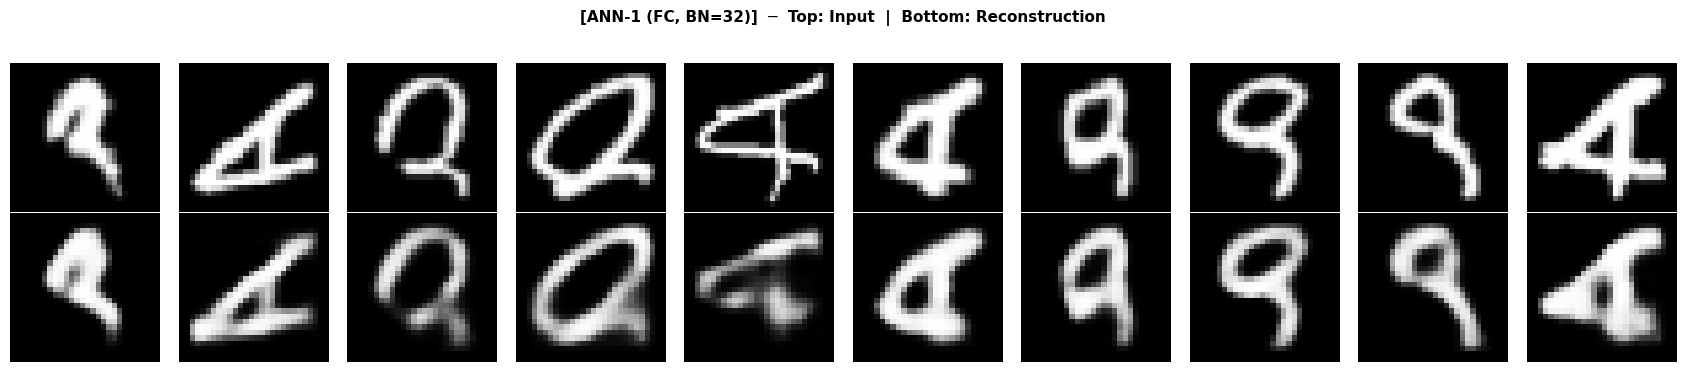

  Saved → /content/outputs/recon_ANN-1_(FC,_BN=32).png


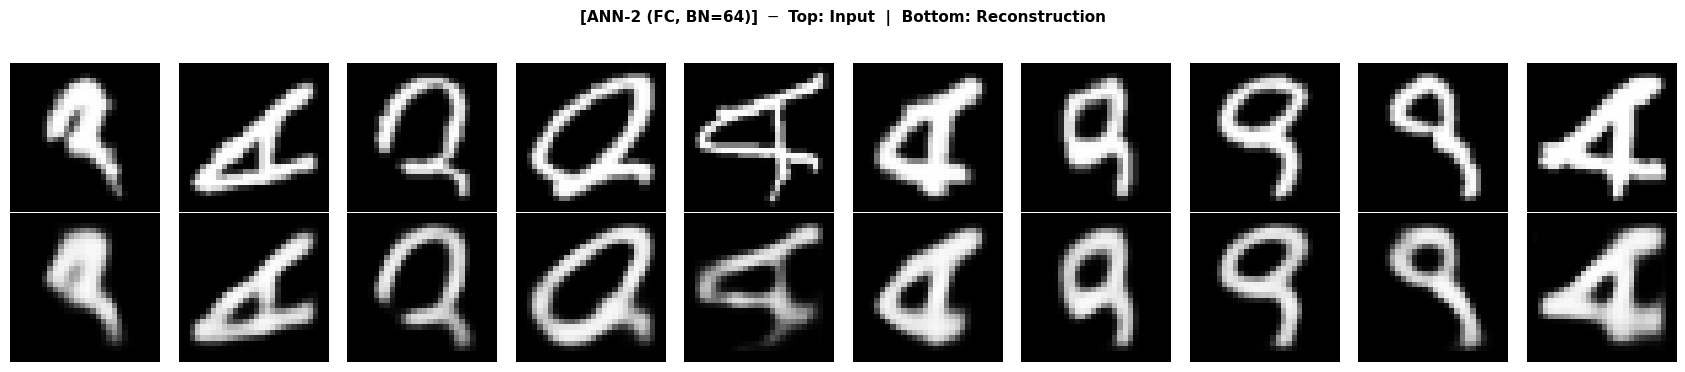

  Saved → /content/outputs/recon_ANN-2_(FC,_BN=64).png


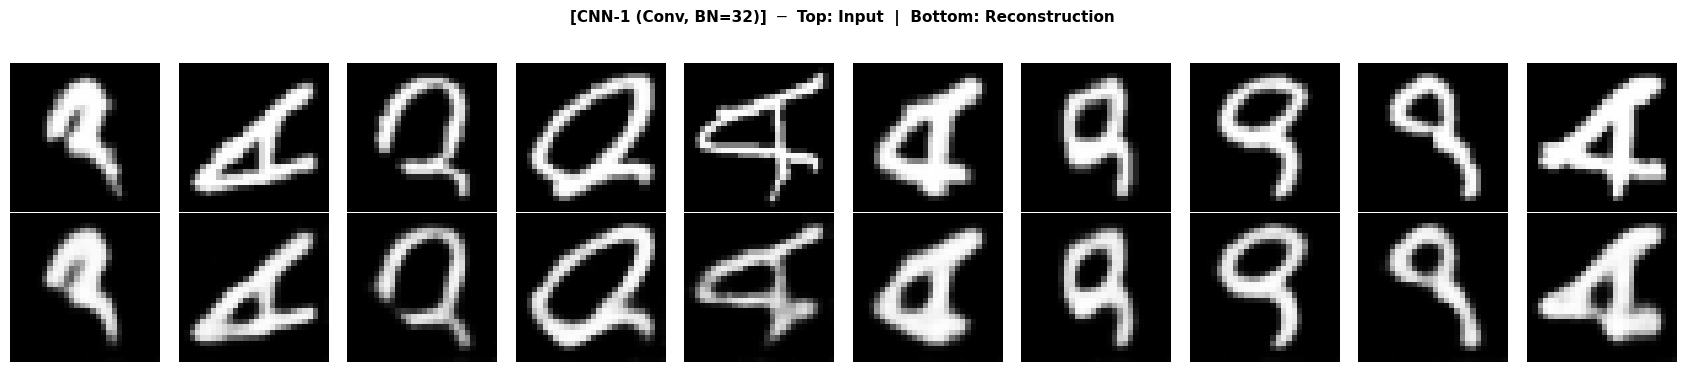

  Saved → /content/outputs/recon_CNN-1_(Conv,_BN=32).png


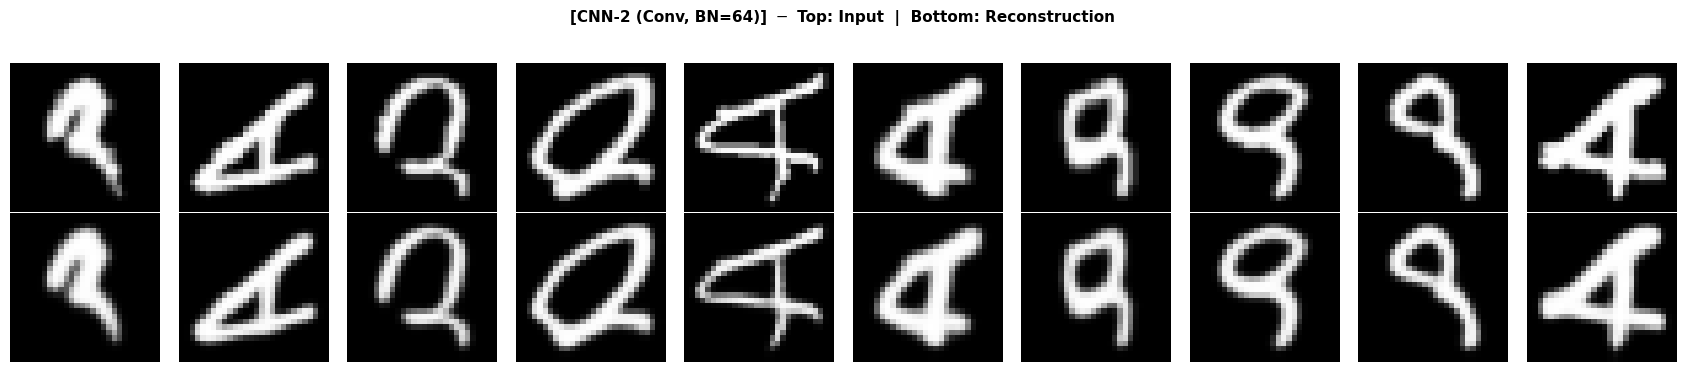

  Saved → /content/outputs/recon_CNN-2_(Conv,_BN=64).png


In [11]:
@torch.no_grad()
def plot_reconstructions(model, name, loader, n=10):
    model.eval()
    imgs, lbls = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    recon, _ = model(imgs)
    imgs, recon = imgs.cpu(), recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.7, 3.6))
    fig.suptitle(f"[{name}]  ─  Top: Input  |  Bottom: Reconstruction",
                 fontsize=11, fontweight='bold', y=1.02)
    for i in range(n):
        ax = axes[0, i]
        ax.imshow(imgs[i].squeeze(),  cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax = axes[1, i]
        ax.imshow(recon[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

    axes[0, 0].set_ylabel("Input", rotation=0, labelpad=48, fontsize=9, va='center')
    axes[1, 0].set_ylabel("Recon.", rotation=0, labelpad=48, fontsize=9, va='center')
    plt.tight_layout()
    path = f"{OUT_DIR}/recon_{name.replace(' ','_').replace('/','-')}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {path}")

for name, model in models_dict.items():
    plot_reconstructions(model, name, test_loader)

### Same Inputs Through All 4 Models

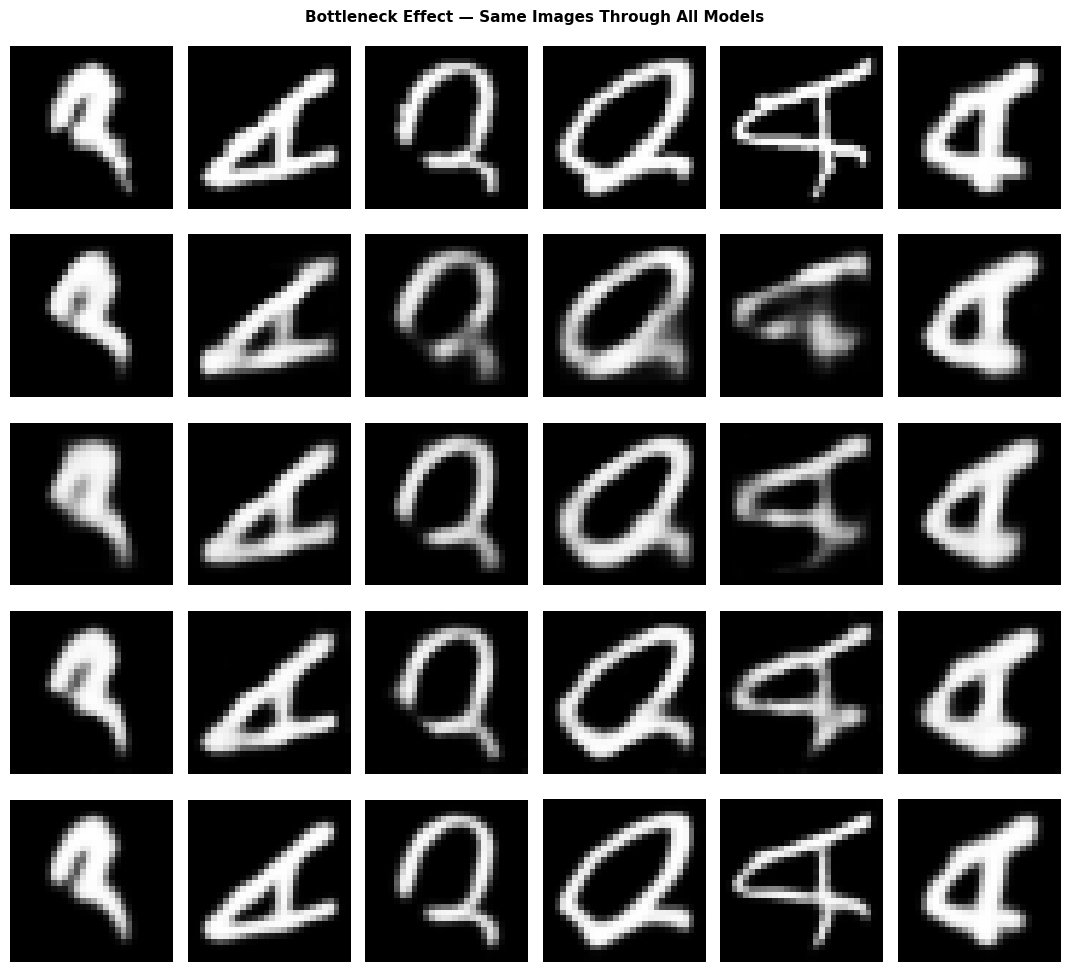

Saved → /content/outputs/bottleneck_comparison.png


In [12]:
@torch.no_grad()
def plot_bottleneck_comparison(models_dict, loader, n=6):
    imgs, _ = next(iter(loader))
    sample = imgs[:n].to(DEVICE)
    recons = {}
    for name, model in models_dict.items():
        model.eval()
        r, _ = model(sample)
        recons[name] = r.cpu()

    rows = ["Original Input"] + list(models_dict.keys())
    data = [sample.cpu()] + [recons[k] for k in models_dict]
    fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.8, len(rows) * 2.0))
    fig.suptitle("Bottleneck Effect — Same Images Through All Models",
                 fontweight='bold', fontsize=11)
    for r, (label, row_data) in enumerate(zip(rows, data)):
        for c in range(n):
            axes[r, c].imshow(row_data[c].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[r, c].axis('off')
        axes[r, 0].set_ylabel(label, rotation=0, labelpad=90, fontsize=8, va='center')
    plt.tight_layout()
    path = f"{OUT_DIR}/bottleneck_comparison.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path}")

plot_bottleneck_comparison(models_dict, test_loader)


## 5. Loss Curve Comparison

Training loss (left) and validation loss (right) for all four models.  
Curves that descend steeply and converge without large train/val gaps indicate good learning.


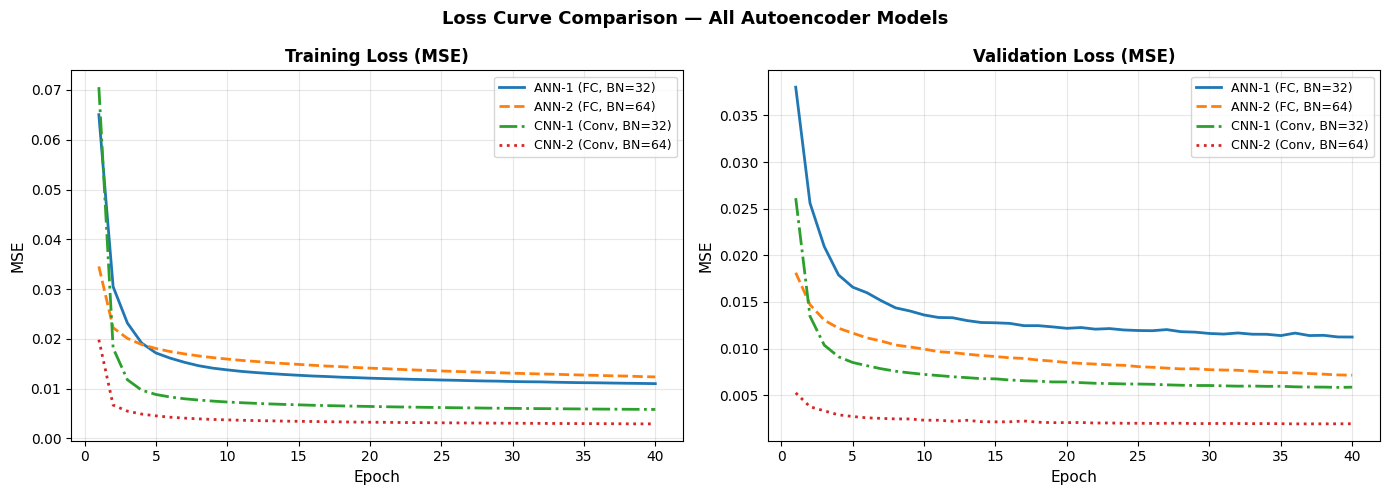

Saved → /content/outputs/loss_curves_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors
styles = ['-', '--', '-.', ':']

for i, (name, (trn, val, _)) in enumerate(history_dict.items()):
    c  = colors[i]
    ep = range(1, len(trn) + 1)
    axes[0].plot(ep, trn, color=c, ls=styles[i], lw=2, label=name)
    axes[1].plot(ep, val, color=c, ls=styles[i], lw=2, label=name)

for ax, title in zip(axes, ["Training Loss (MSE)", "Validation Loss (MSE)"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("MSE", fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Loss Curve Comparison — All Autoencoder Models",
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = f"{OUT_DIR}/loss_curves_comparison.png"
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")


## 6. Latent Space Visualisation

We project the bottleneck vector (32 or 64 dims) to 2D using PCA and t-SNE.  
Each dot = one image.  Colour = letter class (A–Z).

A well-trained autoencoder organises the latent space so that **similar letters cluster together**,
even though the model was never given class labels during training.


In [14]:
@torch.no_grad()
def collect_latents(model, loader, n_batches=25):
    model.eval()
    zs, lbls = [], []
    for i, (imgs, labels) in enumerate(loader):
        if i >= n_batches: break
        _, z = model(imgs.to(DEVICE))
        zs.append(z.cpu().numpy())
        lbls.append(labels.numpy())
    return np.concatenate(zs), np.concatenate(lbls) - 1   # 0-indexed (0=A…25=Z)

LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def plot_latent(model, name, loader, method='pca', n_batches=25):
    zs, labels = collect_latents(model, loader, n_batches)

    if method == 'pca':
        emb = PCA(n_components=2, random_state=SEED).fit_transform(zs)
        suffix = "PCA"
    else:
        # Subsample for speed
        idx = np.random.choice(len(zs), min(3000, len(zs)), replace=False)
        zs, labels = zs[idx], labels[idx]
        emb = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000,
                   learning_rate='auto', init='pca').fit_transform(zs)
        suffix = "t-SNE"

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab20',
                    s=5, alpha=0.65, linewidths=0)
    cbar = plt.colorbar(sc, ax=ax, ticks=range(26))
    cbar.set_ticklabels(LETTERS)
    cbar.set_label("Letter Class", fontsize=10)
    ax.set_title(f"[{name}] Latent Space — {suffix}", fontweight='bold', fontsize=12)
    ax.set_xlabel(f"{suffix} dim 1"); ax.set_ylabel(f"{suffix} dim 2")
    plt.tight_layout()
    path = f"{OUT_DIR}/latent_{name.replace(' ','_')}_{method}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path}")


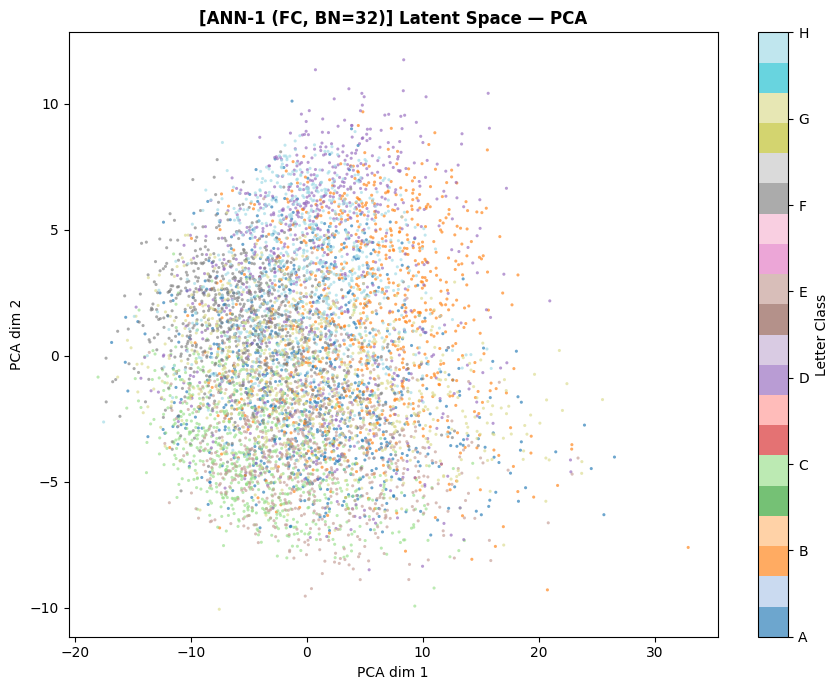

Saved → /content/outputs/latent_ANN-1_(FC,_BN=32)_pca.png


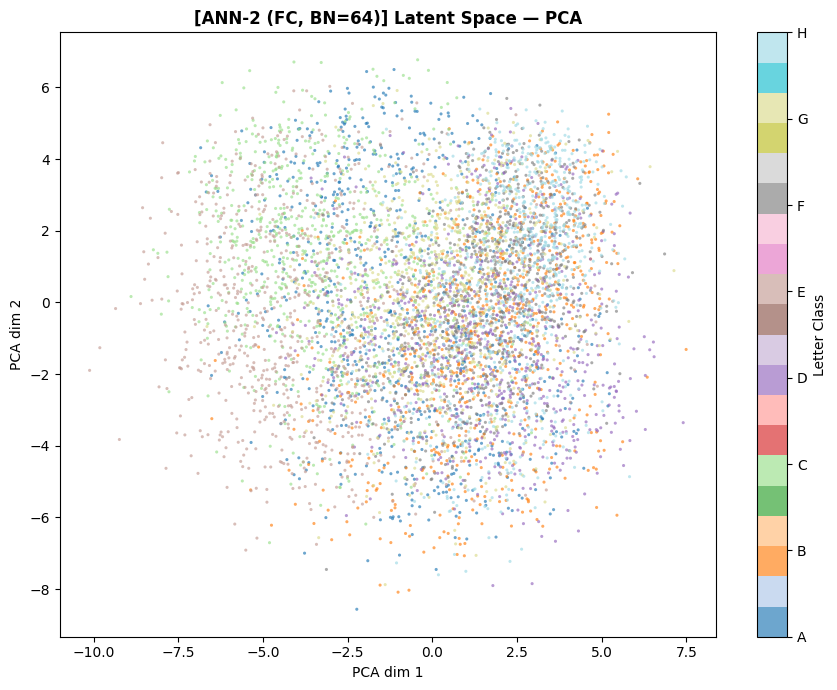

Saved → /content/outputs/latent_ANN-2_(FC,_BN=64)_pca.png


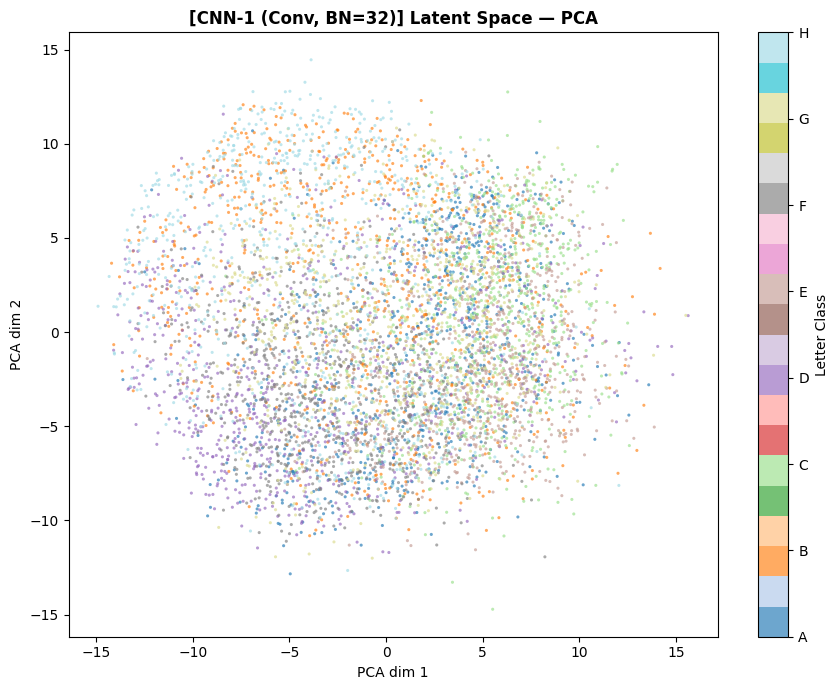

Saved → /content/outputs/latent_CNN-1_(Conv,_BN=32)_pca.png


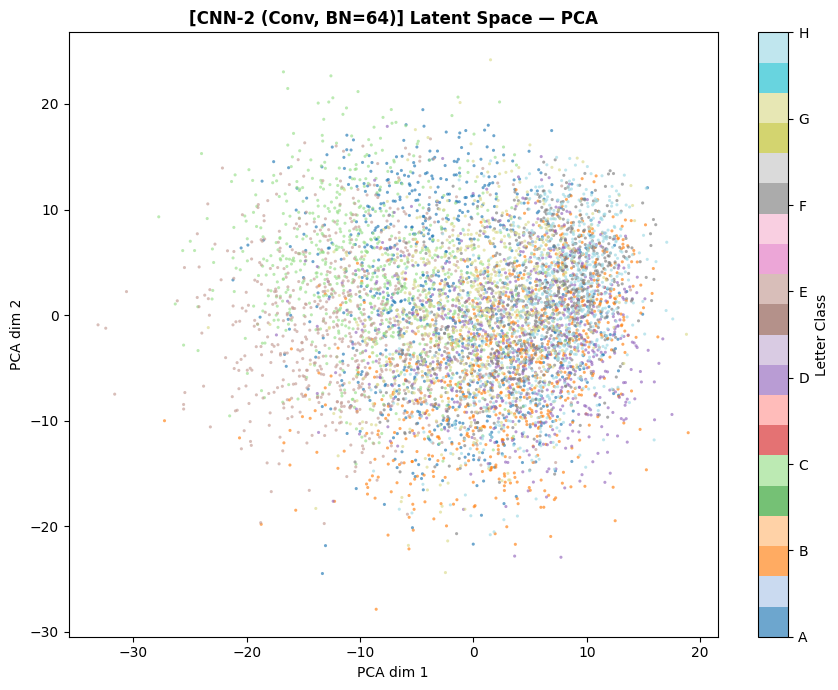

Saved → /content/outputs/latent_CNN-2_(Conv,_BN=64)_pca.png


In [15]:
# PCA latent space — all 4 models
for name, model in models_dict.items():
    plot_latent(model, name, test_loader, method='pca')


Running t-SNE for CNN-2 (Conv, BN=64)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


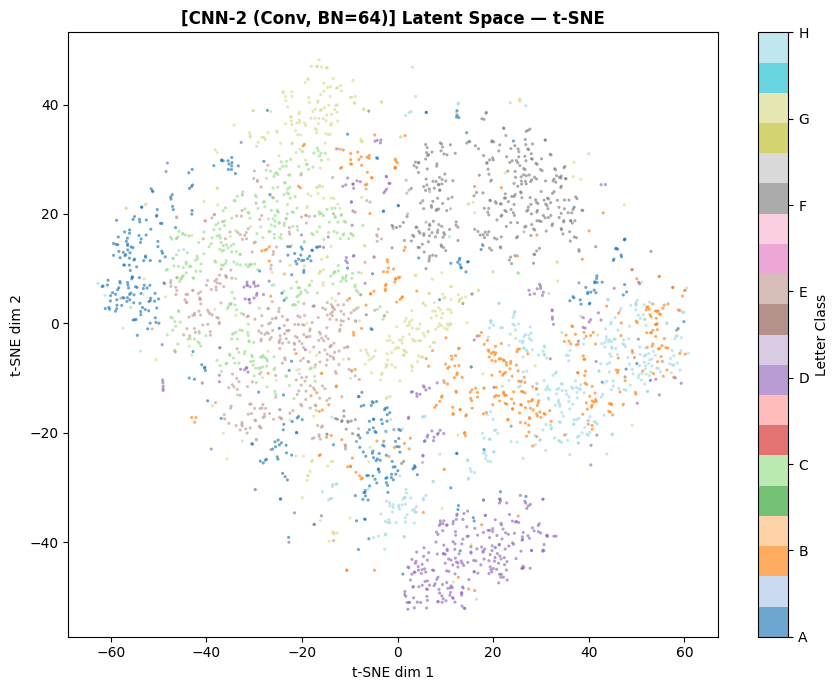

Saved → /content/outputs/latent_CNN-2_(Conv,_BN=64)_tsne.png
Running t-SNE for ANN-2 (FC, BN=64)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


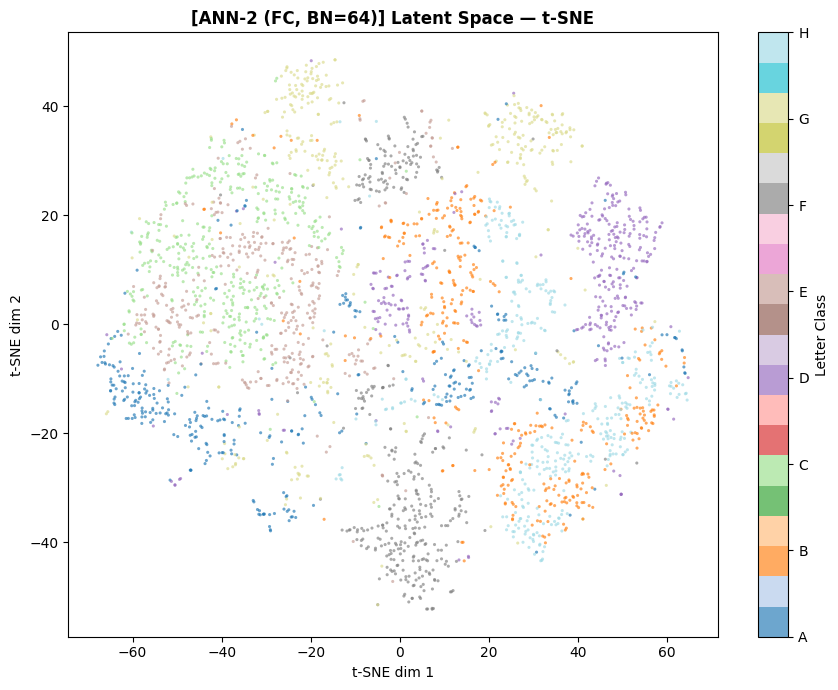

Saved → /content/outputs/latent_ANN-2_(FC,_BN=64)_tsne.png


In [16]:
# t-SNE — two best models (takes ~1 min each)
for name in ["CNN-2 (Conv, BN=64)", "ANN-2 (FC, BN=64)"]:
    print(f"Running t-SNE for {name}...")
    plot_latent(models_dict[name], name, test_loader, method='tsne')


## 7. Model Comparison Summary

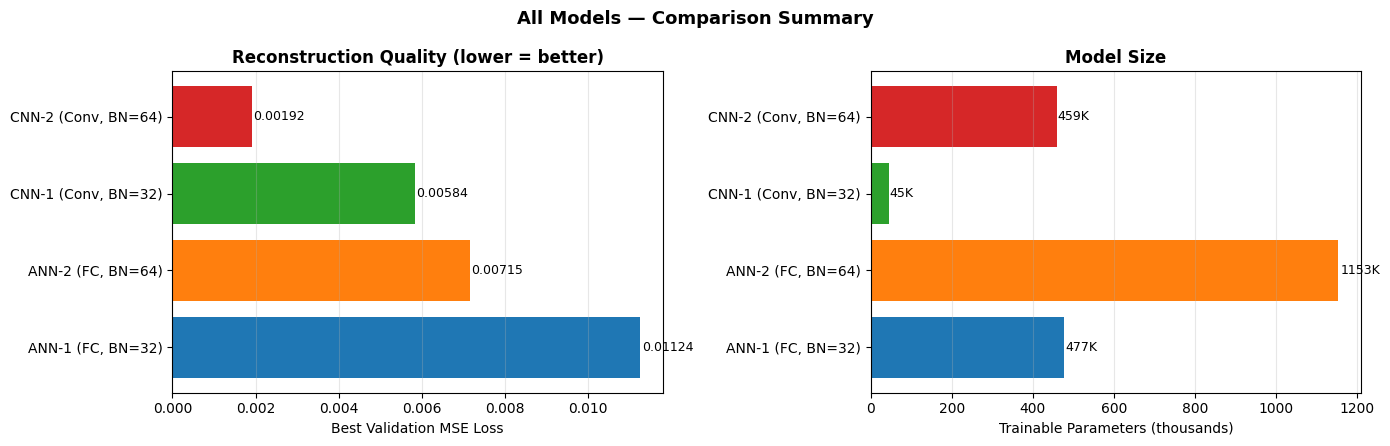


Model                       Params   Best Val MSE  Compression  Rank
────────────────────────────────────────────────────────────────────────
CNN-2 (Conv, BN=64)           459K        0.00192          12×   #1 ★
CNN-1 (Conv, BN=32)            45K        0.00584          24×   #2 +0.39%
ANN-2 (FC, BN=64)            1153K        0.00715          12×   #3 +0.52%
ANN-1 (FC, BN=32)             476K        0.01124          24×   #4 +0.93%


In [17]:
names  = list(history_dict.keys())
vals   = [v for _, _, v in history_dict.values()]
params = [count_params(models_dict[n]) / 1e3 for n in names]
x      = np.arange(len(names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
colors4 = plt.cm.tab10.colors[:4]

bars1 = ax1.barh(x, vals, color=colors4)
ax1.set_yticks(x); ax1.set_yticklabels(names)
ax1.set_xlabel("Best Validation MSE Loss")
ax1.set_title("Reconstruction Quality (lower = better)", fontweight='bold')
for bar, v in zip(bars1, vals):
    ax1.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
             f"{v:.5f}", va='center', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

bars2 = ax2.barh(x, params, color=colors4)
ax2.set_yticks(x); ax2.set_yticklabels(names)
ax2.set_xlabel("Trainable Parameters (thousands)")
ax2.set_title("Model Size", fontweight='bold')
for bar, p in zip(bars2, params):
    ax2.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
             f"{p:.0f}K", va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle("All Models — Comparison Summary", fontsize=13, fontweight='bold')
plt.tight_layout()
path = f"{OUT_DIR}/summary_comparison.png"
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()

best_mse = min(vals)
print(f"\n{'Model':<25} {'Params':>8} {'Best Val MSE':>14} {'Compression':>12}  Rank")
print("─" * 72)
ranked = sorted(history_dict.items(), key=lambda x: x[1][2])
for rank, (name, (_, _, v)) in enumerate(ranked, 1):
    p  = count_params(models_dict[name])
    bn = models_dict[name].bottleneck
    cx = round(784 / bn)
    rel = "★" if rank == 1 else f"+{(v - best_mse)*100:.2f}%"
    print(f"{name:<25} {p//1000:>7}K {v:>14.5f} {cx:>11}×   #{rank} {rel}")


## 8. Save Model Weights

In [18]:
for name, model in models_dict.items():
    fname = name.replace(' ', '_').replace('/', '-').replace('=', '') + ".pt"
    path  = f"{OUT_DIR}/{fname}"
    torch.save({
        'model_state_dict': model.state_dict(),
        'bottleneck': model.bottleneck,
        'val_loss': history_dict[name][2],
        'architecture': name,
    }, path)
    print(f"Saved: {path}")

print(f"\n✅ All done!  Outputs at: {OUT_DIR}/")


Saved: /content/outputs/ANN-1_(FC,_BN32).pt
Saved: /content/outputs/ANN-2_(FC,_BN64).pt
Saved: /content/outputs/CNN-1_(Conv,_BN32).pt
Saved: /content/outputs/CNN-2_(Conv,_BN64).pt

✅ All done!  Outputs at: /content/outputs/


## 9. Key Observations & Discussion

### CNN vs ANN
- CNNs exploit **spatial locality** — convolutions share weights across all pixel positions
- This means CNN-1 (32 BN) achieves comparable or better reconstruction than ANN-2 (64 BN)
  despite having far fewer parameters
- ANN models treat each pixel independently → require more parameters to learn spatial patterns

### Bottleneck 32 vs 64
- BN=32 → **24.5× compression** of the 784-pixel image
- BN=64 → **12.25× compression**
- Larger bottleneck gives better reconstructions but encodes less compressed representations
- In the latent space plots, BN=64 models show more structured / separated clusters

### BatchNorm & Dropout Effect
- ANN-2 and CNN-2 converge more **stably** (smoother loss curves)
- BN prevents internal covariate shift; Dropout prevents co-adaptation of neurons
- Without BN (ANN-1, CNN-1) training can be noisier, especially early epochs

### Latent Space Structure
- PCA and t-SNE of the latent vectors reveal that even without labels,
  **similar letters cluster together** (e.g. C/G/O cluster due to similar curvature)
- CNN-2 typically shows the cleanest class separation — its representations
  capture more discriminative structure because convolutions respect image geometry
